In [92]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph  , START , END
from dotenv import load_dotenv
from typing import TypedDict , Literal
from math import sqrt
from pydantic import BaseModel , Field
load_dotenv()

True

In [93]:
model = ChatGoogleGenerativeAI(model = 'gemini-2.5-flash')

In [94]:
class LLMstate(TypedDict):
    blog : str
    topic : str
    response : Literal['yes' , 'no']

In [95]:
graph = StateGraph(LLMstate)

In [96]:
def gen_blog(state: LLMstate) -> LLMstate:
    topic = state['topic']
    prompt = f"This is Topic = {topic}. write a Blog on this topic"
    result = model.invoke(prompt)
    state["blog"] = result.content

    return state

In [97]:
class evalstruct(BaseModel):
    response: Literal["yes" , "no"] = Field(description = " Does The Blog need improvement ")

In [98]:
eval_llm = model.with_structured_output(evalstruct)

In [ ]:
def evaluation(state: LLMstate) -> LLMstate:
    blog = state["blog"]
    prompt = f"This is my blog = \n {blog} \n. Yu are very Strict teacher tell does the blog need_improvement return yes and if the blog donmt need any improvement return  no"

    result = eval_llm.invoke(prompt)
    state["response"] = result.content

    return state





In [100]:
def condition(state: LLMstate) -> Literal["need_improvement" , END]:
    result = state["response"]
    if result == "yes":
        return "need_improvement"
    elif result == "no":
        return END

In [101]:
def need_improvement(state: LLMstate) -> LLMstate:
    blog = state["blog"]
    prompt = f"this is my bog \n {blog} \n. This need to be improved imporve this blog"
    result = model.invoke(prompt)
    state["blog"] = result.content

    return state

In [102]:
graph.add_node ("gen_blog" , gen_blog)
graph.add_node ("evaluation" , evaluation)
graph.add_node ("need_improvement" , need_improvement)

In [103]:
graph.add_edge(START , "gen_blog")
graph.add_edge("gen_blog" , "evaluation")
graph.add_conditional_edges("evaluation" , condition)
graph.add_edge("need_improvement" , "evaluation")


workflow = graph.compile()

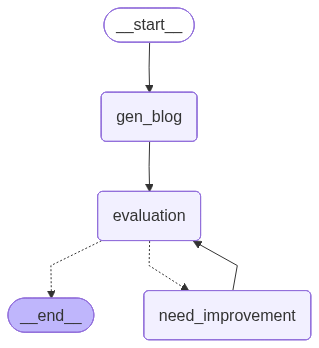

In [104]:
workflow

In [105]:
initial_state = {'topic' : 'LangGraph'}

final_state = workflow.invoke(initial_state)

KeyError: None

In [ ]:
print(final_state)